In [1]:
import json
import pandas as pd

# Load the data from the text file
file_path = 'nbc.txt'

data = []
with open(file_path, 'r', encoding='utf-8') as file:
    for line in file:
        # Each line is a JSON object
        data.append(json.loads(line))

# Convert the data into a pandas DataFrame
df = pd.DataFrame(data)


JSONDecodeError: Expecting value: line 2 column 1 (char 2)

In [7]:
import builtins
import os

# Correct file path
file_path = '/livechat/nbc.txt'

# Check if the file exists
if os.path.exists(file_path):
    # Read the file using builtins' open
    with builtins.open(file_path, 'r', encoding='utf-8') as file:
        lines = file.readlines()

    # Remove any unnecessary newline characters and fix commas
    cleaned_lines = []
    for line in lines:
        line = line.strip()
        if line:  # Ignore empty lines
            cleaned_lines.append(line)

    # Join the cleaned lines into a valid JSON format
    json_data = "[\n" + ",\n".join(cleaned_lines) + "\n]"

    # Saving the cleaned data to a new file safely using builtins' open
    new_file_path = '/mnt/data/fixed_youtube_comments.json'

    with builtins.open(new_file_path, 'w', encoding='utf-8') as new_file:
        new_file.write(json_data)

    print(f"File format has been fixed and saved to {new_file_path}.")
else:
    print(f"File not found: {file_path}")


File not found: /livechat/nbc.txt


In [8]:
# Read and fix the format of the JSON data
file_path = '/livechat/nbc.txt'  # Path to your file

# Reading the file and removing unwanted newlines/spaces
with open(file_path, 'r', encoding='utf-8') as file:
    lines = file.readlines()

# Remove any unnecessary newline characters and fix commas
cleaned_lines = []
for line in lines:
    line = line.strip()
    if line:  # Ignore empty lines
        cleaned_lines.append(line)

# Join the cleaned lines into a valid JSON format
json_data = "[\n" + ",\n".join(cleaned_lines) + "\n]"

# Save the cleaned JSON data to a new file
fixed_file_path = 'fixed_youtube_comments.json'
with open(fixed_file_path, 'w', encoding='utf-8') as fixed_file:
    fixed_file.write(json_data)

print("File format has been fixed and saved to 'fixed_youtube_comments.json'.")


FileNotFoundError: [Errno 2] No such file or directory: '/livechat/nbc.txt'

In [19]:
import builtins

# Safely reading and fixing the format of the JSON data using builtins' open
file_path = './live_reaction.txt'  # Path to your file

# Read the file using builtins' open
with builtins.open(file_path, 'r', encoding='utf-8') as file:
    lines = file.readlines()

# Remove any unnecessary newline characters and fix commas
cleaned_lines = []
for line in lines:
    line = line.strip()
    if line:  # Ignore empty lines
        cleaned_lines.append(line)

# Join the cleaned lines into a valid JSON format
json_data = "\n" + "\n".join(cleaned_lines) + "\n"

# Saving the cleaned data to a new file safely using builtins' open
new_file_path = './live_reaction_PM.json'

with builtins.open(new_file_path, 'w', encoding='utf-8') as new_file:
    new_file.write(json_data)

print(f"File format has been fixed and saved to {new_file_path}.")



File format has been fixed and saved to ./live_reaction_PM.json.


In [61]:
import pandas as pd
import json

# Load JSON file
file_path = './live_reaction_PM.json'
with open(file_path, 'r') as file:
    data = json.load(file)

# Convert to pandas DataFrame
df = pd.DataFrame(data)
print(df.head())  # Preview the dataset


             timestamp                author  \
0  2024-09-10 21:45:11  SkullKingofCarpathia   
1  2024-09-10 21:45:12               tee gee   
2  2024-09-10 21:45:12             Messiah66   
3  2024-09-10 21:45:13                ItzBwo   
4  2024-09-10 21:45:13              SoapGirl   

                                             message  
0                                    He was rambling  
1  those "journalists" are being disrespectful of...  
2                          Where’s this 2 min clock   
3                                                Lie  
4                                                  T  


In [62]:
# Check for missing values
print(df.isnull().sum())

timestamp    0
author       0
message      0
dtype: int64


In [63]:
# Check data types and basic info
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3702 entries, 0 to 3701
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   timestamp  3702 non-null   object
 1   author     3702 non-null   object
 2   message    3702 non-null   object
dtypes: object(3)
memory usage: 86.9+ KB
None


In [64]:
# Convert 'timestamp' to datetime
df['timestamp'] = pd.to_datetime(df['timestamp'])
print(df['timestamp'].head())


0   2024-09-10 21:45:11
1   2024-09-10 21:45:12
2   2024-09-10 21:45:12
3   2024-09-10 21:45:13
4   2024-09-10 21:45:13
Name: timestamp, dtype: datetime64[ns]


In [66]:
# Count unique authors
unique_authors = df['author'].nunique()
print(f'Number of unique authors: {unique_authors}')


Number of unique authors: 1316


In [67]:
# Group comments by hour
df['hour'] = df['timestamp'].dt.hour
comments_per_hour = df.groupby('hour').size()
print(comments_per_hour)


hour
21    1002
22    2700
dtype: int64


In [68]:
# Add word count for each message
df['word_count'] = df['message'].apply(lambda x: len(x.split()))
print(df[['message', 'word_count']].head())


                                             message  word_count
0                                    He was rambling           3
1  those "journalists" are being disrespectful of...          14
2                          Where’s this 2 min clock            5
3                                                Lie           1
4                                                  T           1


In [69]:
from collections import Counter
import re

# Combine all comments into a single text
all_comments = ' '.join(df['message'])

# Tokenize and clean the words
words = re.findall(r'\b\w+\b', all_comments.lower())

# Find the most common words
common_words = Counter(words).most_common(10)
print(common_words)


[('he', 1001), ('the', 741), ('blue_heart', 728), ('is', 695), ('to', 527), ('a', 489), ('trump', 475), ('s', 446), ('him', 418), ('and', 350)]


/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


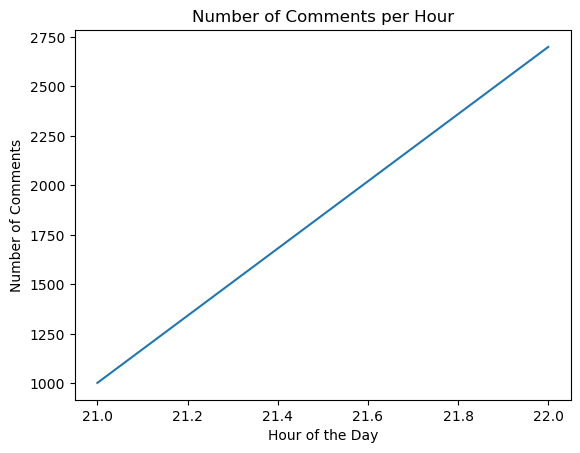

In [70]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot comments per hour
sns.lineplot(x=comments_per_hour.index, y=comments_per_hour.values)
plt.title('Number of Comments per Hour')
plt.xlabel('Hour of the Day')
plt.ylabel('Number of Comments')
plt.show()


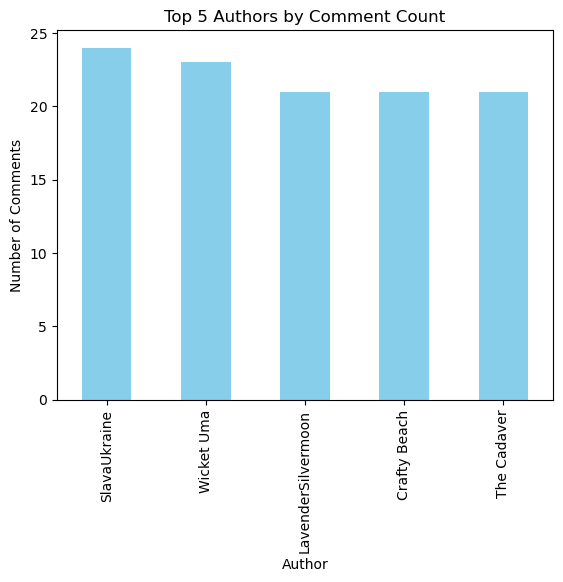

In [71]:
# Top 5 authors
top_authors = df['author'].value_counts().head(5)

# Bar plot of top 5 authors
top_authors.plot(kind='bar', color='skyblue')
plt.title('Top 5 Authors by Comment Count')
plt.xlabel('Author')
plt.ylabel('Number of Comments')
plt.show()

In [30]:
from textblob import TextBlob

# Perform sentiment analysis on the message column
df['sentiment'] = df['message'].apply(lambda x: TextBlob(x).sentiment.polarity)

# Summary of sentiments
print(df['sentiment'].describe())

ModuleNotFoundError: No module named 'textblob'

In [41]:
python -m pip install textblob

SyntaxError: invalid syntax (2015784405.py, line 1)